# 1. Intro

Hierarchical Clustering(HC) is an unsupervised algorithms that that groups data into a hierarchy of clusters based on similarity. It builds a tree‑like structure (dendrogram) that helps visualize relationships and decide the optimal number of clusters.
Some feature abouts HC is:
* Does not require pre‑selecting the number of clusters.(an advandtage to Kmean clustering)
* Uses agglomerative or divisive approaches.
* Commonly applied in data exploration and pattern discovery.
* It is commonly used in pattern recognition, customer segmentation and image grouping.

For example:
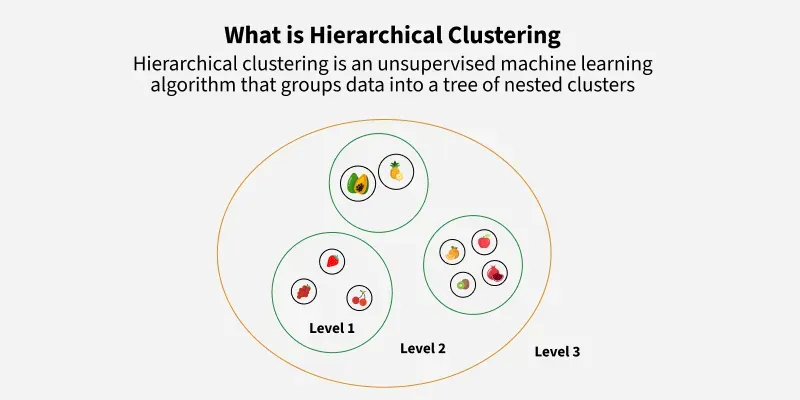
    Imagine we have four fruits with different weights: an apple (100g), a banana (120g), a cherry (50g) and a grape (30g). Hierarchical clustering starts by treating each fruit as its own group.

1. Start with each fruit as its own cluster.
2. Merge the closest items: grape (30g) and cherry (50g) are grouped first.
3. Next, apple (100g) and banana (120g) are grouped.
4. Finally, these two clusters merge into one.
5. Finally all the fruits are merged into one large group, showing how hierarchical clustering progressively combines the most similar data points.



Dendrogram
A dendrogram is like a family tree for clusters. It shows how individual data points or groups of data merge together. The bottom shows each data point as its own group and as we move up, similar groups are combined.

The lower the merge point, the more similar the groups are. It helps us see how things are grouped step by step.

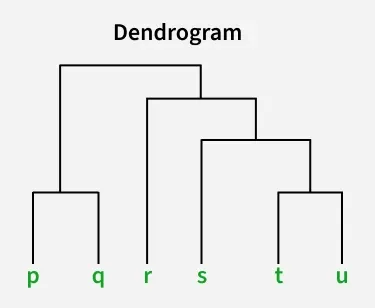
1. At the bottom of the dendrogram the points P, Q, R, S and T are all separate.
2. As we move up, the closest points are merged into a single group.
3. The lines connecting the points show how they are progressively merged based on similarity.
4. The height at which they are connected shows how similar the points are to each other; the shorter the line the more similar they are

# 2. Theory - Solving mathematics problems
There are two main types of hierarchical clustering.
1. Agglomerative Clustering
2. Divisive clustering

1. Hierarchical Agglomerative Clustering
It is also known as the bottom-up approach or hierarchical agglomerative clustering (HAC). Bottom-up algorithms treat each data as a singleton cluster at the outset and then successively agglomerate pairs of clusters until all clusters have been merged into a single cluster that contains all data. 

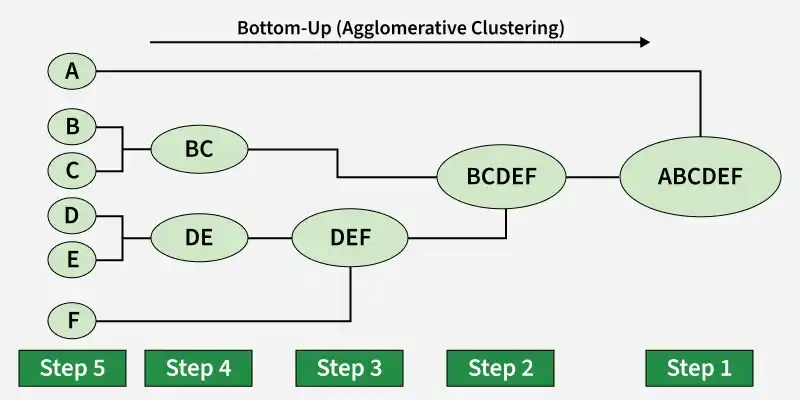

Workflow for Hierarchical Agglomerative clustering:
1. Start with individual points: Each data point is its own cluster. For example if we have 5 data points we start with 5 clusters each containing just one data point.
2. Calculate distances between clusters: Calculate the distance between every pair of clusters. 
3. Initially since each cluster has one point this is the distance between the two data points.
4. Merge the closest clusters: Identify the two clusters with the smallest distance and merge them into a single cluster.
5. Update distance matrix: After merging we now have one less cluster. Recalculate the distances between the new cluster and the remaining clusters.
6. Repeat steps 3 and 4: Keep merging the closest clusters and updating the distance matrix until we have only one cluster left.
7. Create a dendrogram: As the process continues we can visualize the merging of clusters using a tree-like diagram called a dendrogram. It shows the hierarchy of how clusters are merged.

2. Hierarchical Divisive clustering
Divisive clustering is also known as a top-down approach. Top-down clustering requires a method for splitting a cluster that contains the whole data and proceeds by splitting clusters recursively until individual data have been split into singleton clusters.

Workflow for Hierarchical Divisive clustering : 
1. Start with all data points in one cluster: Treat the entire dataset as a single large cluster.
2. Split the cluster: Divide the cluster into two smaller clusters. The division is typically done by finding the two most dissimilar points in the cluster and using them to separate the data into two parts.
3. Repeat the process: For each of the new clusters, repeat the splitting process: Choose the cluster with the most dissimilar points and split it again into two smaller clusters.
4. Stop when each data point is in its own cluster: Continue this process until every data point is its own cluster or the stopping condition (such as a predefined number of clusters) is met.

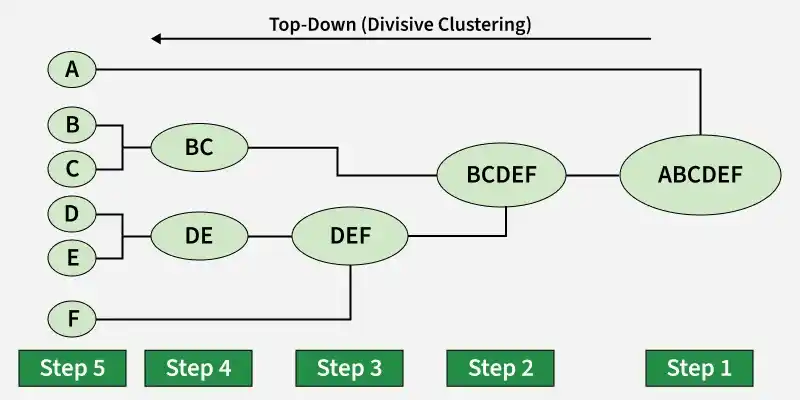

# 3. Apply in Python

Let's see the implementation of Agglomerative Clustering,

* Start with each data point as its own cluster.
* Compute distances between all clusters.
* Merge the two closest clusters based on a linkage method.
* Update the distances to reflect the new cluster.
* Repeat merging until the desired number of clusters or one cluster remains.
* The dendrogram visualizes these merges as a tree, showing cluster relationships and distances.


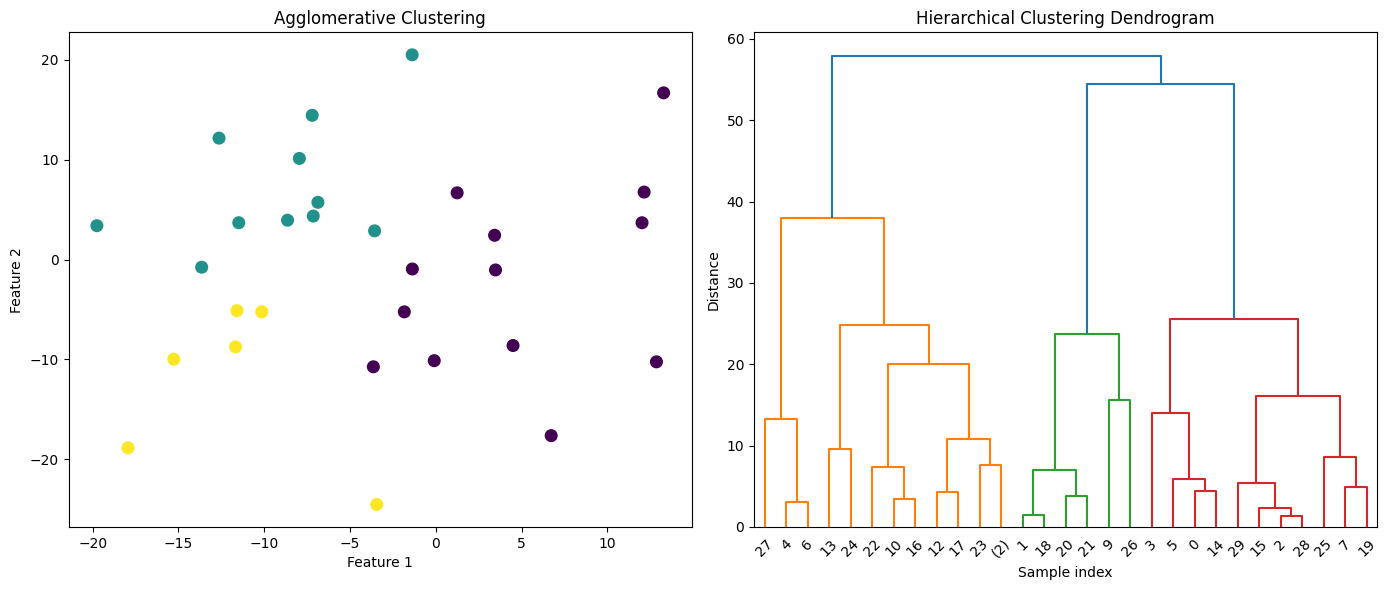

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram
from sklearn.datasets import make_blobs

X, _ = make_blobs(n_samples=30, centers=3, cluster_std=10, random_state=42)

clustering = AgglomerativeClustering(n_clusters=3)
labels = clustering.fit_predict(X)

agg = AgglomerativeClustering(distance_threshold=0, n_clusters=None)
agg.fit(X)


def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)

    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]).astype(float)
    dendrogram(linkage_matrix, **kwargs)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=70)
ax1.set_title("Agglomerative Clustering")
ax1.set_xlabel("Feature 1")
ax1.set_ylabel("Feature 2")

plt.sca(ax2)
plot_dendrogram(agg, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample index")
plt.ylabel("Distance")

plt.tight_layout()
plt.show()

Let's see the implementation of Divisive Clustering,

* Starts with all data points as one big cluster.
* Finds the largest cluster and splits it into two using KMeans.
* Repeats splitting the largest cluster until reaching the desired number of clusters.
* Assigns cluster labels to each data point based on the splits.
* Returns history of clusters at each step and final labels.
* Visualizes data points colored by their final cluster.

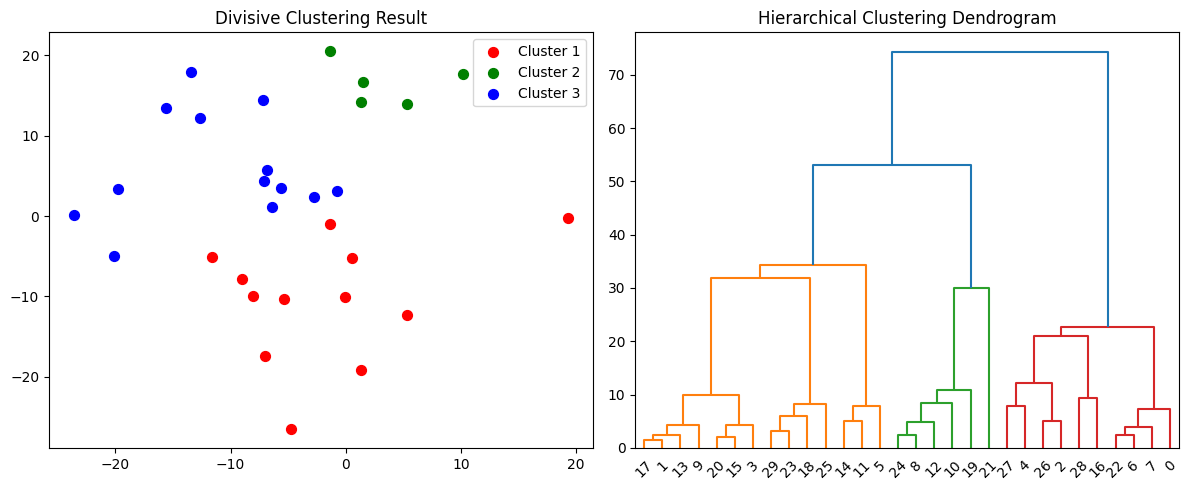

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from scipy.cluster.hierarchy import dendrogram, linkage

X, _ = make_blobs(n_samples=30, centers=5, cluster_std=10, random_state=42)


def divisive_clustering(data, max_clusters=3):
    clusters = [data]
    while len(clusters) < max_clusters:
        cluster_to_split = max(clusters, key=lambda x: len(x))
        clusters.remove(cluster_to_split)

        kmeans = KMeans(n_clusters=2, random_state=42).fit(cluster_to_split)
        cluster1 = cluster_to_split[kmeans.labels_ == 0]
        cluster2 = cluster_to_split[kmeans.labels_ == 1]

        clusters.extend([cluster1, cluster2])
    return clusters


clusters = divisive_clustering(X, max_clusters=3)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
colors = ['r', 'g', 'b', 'c', 'm', 'y']
for i, cluster in enumerate(clusters):
    plt.scatter(cluster[:, 0], cluster[:, 1], s=50,
                c=colors[i], label=f'Cluster {i+1}')
plt.title('Divisive Clustering Result')
plt.legend()

linked = linkage(X, method='ward')

plt.subplot(1, 2, 2)
dendrogram(linked, orientation='top',
           distance_sort='descending', show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')

plt.tight_layout()
plt.show()

# Computing Distance Matrix
While merging two clusters we check the distance between two every pair of clusters and merge the pair with the least distance/most similarity. But the question is how is that distance determined. There are different ways of defining Inter Cluster distance/similarity. Some of them are:

* Min Distance: Find the minimum distance between any two points of the cluster.
* Max Distance: Find the maximum distance between any two points of the cluster.
* Group Average: Find the average distance between every two points of the clusters.
* Ward's Method: The similarity of two clusters is based on the increase in squared error when two clusters are merged.

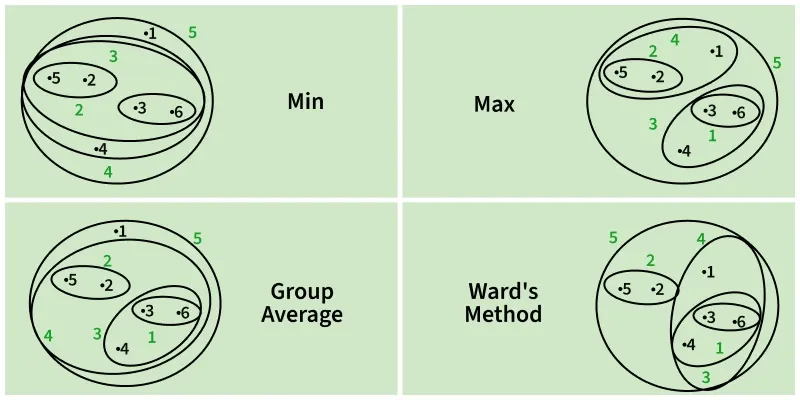

The image compares cluster distance methods:

* Min uses the shortest distance between clusters
* Max uses the longest
* Group Average computes the mean of all pairwise distances
* Ward’s method minimizes the increase in within-cluster variance during merging